# 22b — Surrogate Trees Only

For each decision-point gateway, fit a decision tree whose target is the
**LSTM's predicted next activity** (the "surrogate"). Shows the rules the
LSTM effectively learned, without comparing to ground-truth process logic.

See `22_gateway_decision_analysis.ipynb` for the full LSTM vs. ground-truth
comparison.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [ ]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from src.interpretability.surrogate.c45_tree import C45Classifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- Feature indices ---
ACT_IDX = 0    # Activity
RES_IDX = 1    # Resource
VAR_IDX = 2    # Variant index (case-level)

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

## Build DFG and identify qualifying gateways

In [3]:
MIN_CASES = 50       # minimum prefixes at this gateway
MIN_BRANCH = 10      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 20

ACTIVITY_WINDOW = 10                # number of recent events to include as positional features
CASE_LEVEL_THRESHOLD = 0.95     # feature is case-level if it's constant within a case in >=95% of cases

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Data-driven classification: event-level vs case-level ---
# A feature is case-level if at least CASE_LEVEL_THRESHOLD of cases have a single
# constant value across all real (non-EOS) events of the case.
_n_cat_const = [0] * n_cat
_n_num_const = [0] * n_num
_total_checked = 0
for _cid, (_idx, _L) in cases.items():
    _cat_t, _num_t, _ = dataset[_idx]
    _s = seq_len - _L
    _useful = _L
    for _j in range(_L - 1, -1, -1):
        if _cat_t[ACT_IDX][_s + _j].item() == eos_idx:
            _useful = _j
        else:
            break
    if _useful == 0:
        continue
    _total_checked += 1
    for _ci in range(n_cat):
        _vals = _cat_t[_ci][_s:_s + _useful].tolist()
        if len(set(_vals)) == 1:
            _n_cat_const[_ci] += 1
    for _ni in range(n_num):
        _vals = _num_t[_ni][_s:_s + _useful].tolist()
        if max(_vals) - min(_vals) < 1e-6:
            _n_num_const[_ni] += 1

EVENT_CAT_INDICES = [i for i in range(n_cat)
                     if _n_cat_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]
EVENT_NUM_INDICES = [i for i in range(n_num)
                     if _n_num_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]

print(f'\nFeature classification (threshold: {CASE_LEVEL_THRESHOLD:.0%} constant -> case-level, '
      f'based on {_total_checked} cases):')
for _ci in range(n_cat):
    _pct = _n_cat_const[_ci] / _total_checked
    _tag = 'event-level' if _ci in EVENT_CAT_INDICES else 'CASE-LEVEL'
    print(f'  cat[{_ci}] {decoder.cat_features[_ci]:35s} {_pct:5.1%} constant  -> {_tag}')
for _ni in range(n_num):
    _pct = _n_num_const[_ni] / _total_checked
    _tag = 'event-level' if _ni in EVENT_NUM_INDICES else 'CASE-LEVEL'
    print(f'  num[{_ni}] {decoder.num_features[_ni]:35s} {_pct:5.1%} constant  -> {_tag}')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

916 unique cases

Feature classification (threshold: 95% constant -> case-level, based on 916 cases):
  cat[0] Activity                             0.0% constant  -> event-level
  cat[1] Resource                             0.0% constant  -> event-level
  cat[2] Variant index                       100.0% constant  -> CASE-LEVEL
  cat[3] seriousness                         100.0% constant  -> CASE-LEVEL
  cat[4] customer                            99.8% constant  -> CASE-LEVEL
  cat[5] product                             99.9% constant  -> CASE-LEVEL
  cat[6] responsible_section                 100.0% constant  -> CASE-LEVEL
  cat[7] seriousness_2                       97.5% constant  -> CASE-LEVEL
  cat[8] service_level                       98.7% constant  -> CASE-LEVEL
  cat[9] service_type                        99.9% constant  -> CASE-LEVEL
  cat[10] support_section                     100.0% constant  -> CASE-LEVEL
  cat[11] workgroup                           99.9% constant  -> C

## Collect per-gateway prefixes and LSTM predictions

In [4]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract features for a single prefix.

    Kept minimal: prefix_length, case-level features (cat + num) at the gateway
    position, and positional encoding over the last ACTIVITY_WINDOW events for
    every event-level categorical AND numerical feature.
    """
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    feats = {'prefix_length': prefix_len}

    # Case-level categorical features (event-level ones are covered by positional features below)
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci in EVENT_CAT_INDICES:
            continue
        val = cat_tuple[ci][end - 1].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))

    # Case-level numerical features (event-level ones are covered by positional features below)
    for ni, feat_name in enumerate(decoder.num_features):
        if ni in EVENT_NUM_INDICES:
            continue
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(
            feat_name, num_tuple[ni][end - 1].item())

    # Positional features for every event-level categorical feature (last ACTIVITY_WINDOW events)
    for ci in EVENT_CAT_INDICES:
        feat_name = decoder.cat_features[ci]
        tensor = cat_tuple[ci][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_categorical_value(ci, tensor[pos].item())
            else:
                feats[key] = '<pad>'

    # Positional features for every event-level numerical feature (last ACTIVITY_WINDOW events)
    for ni in EVENT_NUM_INDICES:
        feat_name = decoder.num_features[ni]
        tensor = num_tuple[ni][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_numerical_value(feat_name, tensor[pos].item())
            else:
                feats[key] = float('nan')

    return feats


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Find all positions where activity == gateway and next activity exists
        for k in range(useful_len - 1):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')


Assign seriousness: 995 prefixes, 5 actual branches, 2 LSTM branches, LSTM accuracy=0.509
  Actual distribution: Assign seriousness (96), Require upgrade (1), Resolve ticket (50), Take in charge ticket (837), Wait (11)
  LSTM   distribution: Resolve ticket (400), Take in charge ticket (595)

Take in charge ticket: 996 prefixes, 6 actual branches, 3 LSTM branches, LSTM accuracy=0.674
  Actual distribution: Create SW anomaly (7), Require upgrade (12), Resolve ticket (717), Schedule intervention (1), Take in charge ticket (16), Wait (243)
  LSTM   distribution: Closed (19), Resolve ticket (833), Take in charge ticket (144)

Resolve ticket: 987 prefixes, 4 actual branches, 3 LSTM branches, LSTM accuracy=0.937
  Actual distribution: Closed (910), RESOLVED (1), Resolve ticket (50), Take in charge ticket (26)
  LSTM   distribution: Closed (948), Resolve ticket (38), Take in charge ticket (1)

Wait: 279 prefixes, 6 actual branches, 3 LSTM branches, LSTM accuracy=0.631
  Actual distribution: A

## Train surrogate trees

Target = LSTM's predicted next activity. A stratified 60/20/20 train/validation/test
split is used. Depth is swept on the validation set and the shallowest tree within
2% of the best validation score is selected. Final fidelity (agreement with the
LSTM on the held-out test set) is reported.

In [5]:
def select_best_depth(X_train, y_train, X_val, y_val, cat_features,
                      depths=(3, 4, 5, 6, 7, 8, None)):
    """Sweep depths on validation set; prefer shallowest within 2% of best."""
    results = []
    for depth in depths:
        clf = C45Classifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train, categorical_features=cat_features)
        results.append({'depth': depth,
                        'train': clf.score(X_train, y_train),
                        'val': clf.score(X_val, y_val),
                        'clf': clf})
    best_idx = 0
    best_val = results[0]['val']
    for i in range(1, len(results)):
        if results[i]['val'] > best_val + 0.02:
            best_idx = i
            best_val = results[i]['val']
    return results[best_idx]['clf'], results


# --- Train surrogate tree (target: LSTM prediction) per gateway ---
surrogate_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    # Three-way split targeting the LSTM labels
    try:
        X_tv, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_lstm)
    except ValueError:
        X_tv, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2, random_state=42)
    try:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_tv, y_lstm_tv, y_actual_tv, test_size=0.25,
                             random_state=42, stratify=y_lstm_tv)
    except ValueError:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_tv, y_lstm_tv, y_actual_tv, test_size=0.25, random_state=42)

    clf, sweep = select_best_depth(X_train, y_lstm_train, X_val, y_lstm_val, cat_cols)

    fidelity = clf.score(X_test, y_lstm_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()

    surrogate_results[gateway_act] = {
        'clf': clf,
        'sweep': sweep,
        'feature_names': list(X.columns),
        'cat_cols': cat_cols,
        'X_test': X_test,
        'y_lstm_test': y_lstm_test,
        'y_actual_test': y_actual_test,
        'fidelity': fidelity,
        'lstm_accuracy': lstm_accuracy,
        'n_cases': len(X),
    }

    print(f'{gateway_act}: n={len(X)}, fidelity={fidelity:.3f}, '
          f'depth={clf.get_depth()}, leaves={clf.get_n_leaves()}, '
          f'LSTM accuracy={lstm_accuracy:.3f}')

Assign seriousness: n=995, fidelity=0.598, depth=2, leaves=3, LSTM accuracy=0.492
Take in charge ticket: n=996, fidelity=0.835, depth=3, leaves=4, LSTM accuracy=0.670
Resolve ticket: n=987, fidelity=0.975, depth=2, leaves=3, LSTM accuracy=0.934
Wait: n=279, fidelity=0.714, depth=1, leaves=2, LSTM accuracy=0.714


## Summary table

In [6]:
summary_rows = []
for gateway_act, gr in surrogate_results.items():
    fn = gr['feature_names']
    imp = gr['clf'].feature_importances_
    top = fn[int(np.argmax(imp))]
    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["fidelity"]:.3f}',
        'Depth': gr['clf'].get_depth(),
        'Leaves': gr['clf'].get_n_leaves(),
        'Top Feature': top,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,LSTM Accuracy,Surrogate Fidelity,Depth,Leaves,Top Feature
0,Assign seriousness,995,0.492,0.598,2,3,seconds_in_day_pos_-2
1,Take in charge ticket,996,0.670,0.835,3,4,day_in_week_pos_-3
2,Resolve ticket,987,0.934,0.975,2,3,case_elapsed_time_pos_-4
3,Wait,279,0.714,0.714,1,2,event_elapsed_time_pos_-4


## Feature importance (surrogate)

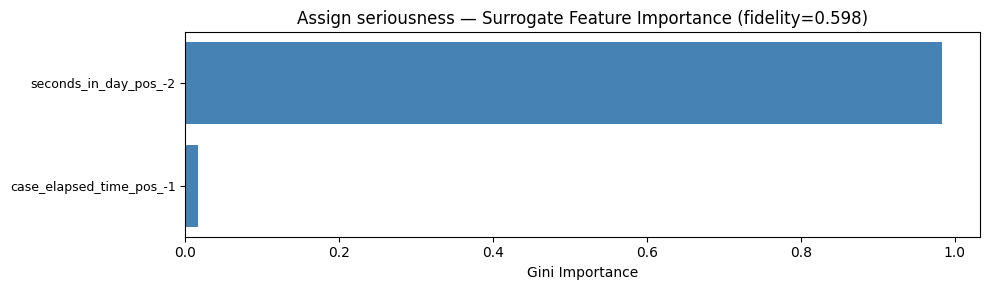

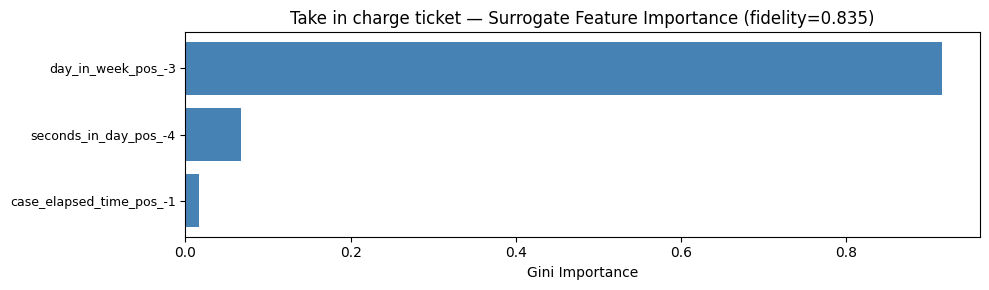

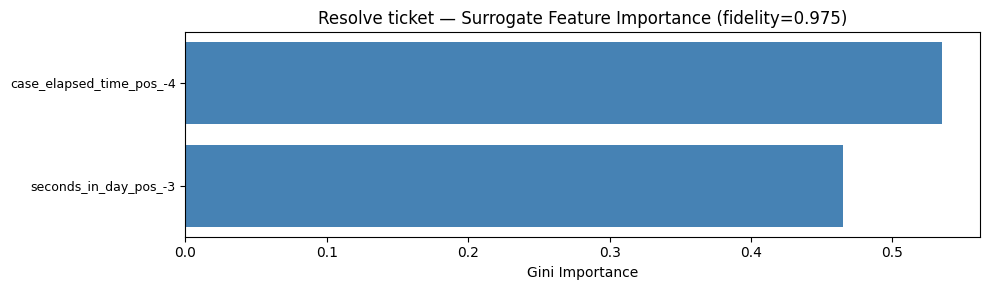

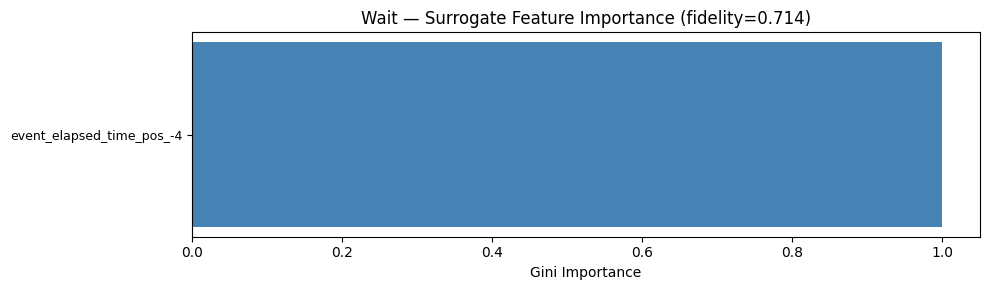

In [7]:
for gateway_act, gr in surrogate_results.items():
    fn = gr['feature_names']
    imp = gr['clf'].feature_importances_

    mask = imp > 0
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_nz = imp[mask]
    order = np.argsort(imp_nz)[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_nz = imp_nz[order]

    fig, ax = plt.subplots(figsize=(10, max(3, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    ax.barh(y_pos, imp_nz, color='steelblue')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Surrogate Feature Importance '
                 f'(fidelity={gr["fidelity"]:.3f})')
    plt.tight_layout()
    plt.show()

## Decision rules (surrogate)

In [8]:
for gateway_act, gr in surrogate_results.items():
    clf = gr['clf']
    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')
    print(f'  fidelity={gr["fidelity"]:.3f}, depth={clf.get_depth()}, leaves={clf.get_n_leaves()}')
    print(f'  {"-" * 70}')

    rules = clf.extract_rules()
    for i, rule in enumerate(rules):
        conds = '\n      AND '.join(rule['conditions']) or '(root)'
        print(f'  Rule {i + 1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN -> {rule["prediction"]}')
        print()

GATEWAY: Assign seriousness
  fidelity=0.598, depth=2, leaves=3
  ----------------------------------------------------------------------
  Rule 1 (n=35, 80% confidence):
    IF  seconds_in_day_pos_-2 > 3.302e+04
      AND case_elapsed_time_pos_-1 > 2543
    THEN -> Take in charge ticket

  Rule 2 (n=25, 100% confidence):
    IF  seconds_in_day_pos_-2 > 3.302e+04
      AND case_elapsed_time_pos_-1 <= 2543
    THEN -> Take in charge ticket

  Rule 3 (n=20, 90% confidence):
    IF  seconds_in_day_pos_-2 <= 3.302e+04
    THEN -> Take in charge ticket

GATEWAY: Take in charge ticket
  fidelity=0.835, depth=3, leaves=4
  ----------------------------------------------------------------------
  Rule 1 (n=34, 74% confidence):
    IF  day_in_week_pos_-3 <= 3.5
      AND seconds_in_day_pos_-4 <= 4.953e+04
      AND case_elapsed_time_pos_-1 > 6.407e+05
    THEN -> Resolve ticket

  Rule 2 (n=26, 100% confidence):
    IF  day_in_week_pos_-3 > 3.5
    THEN -> Resolve ticket

  Rule 3 (n=21, 100% con

## Surrogate trees rendered as images

One matplotlib figure per gateway. Orange nodes are internal splits; blue nodes
are leaves with the predicted class, sample count and confidence.

In [1]:
def plot_c45_tree(clf, title=''):
    """Render a C4.5 surrogate tree as a matplotlib figure."""
    root = clf.root_
    if root is None:
        return None

    positions = {}
    leaf_counter = [0]

    def assign_x(node, depth):
        if not node.children:
            positions[id(node)] = (leaf_counter[0], -depth)
            leaf_counter[0] += 1
            return positions[id(node)][0]
        child_xs = [assign_x(c, depth + 1) for c in node.children]
        x = (min(child_xs) + max(child_xs)) / 2.0
        positions[id(node)] = (x, -depth)
        return x

    assign_x(root, 0)
    max_depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()

    fig_w = min(22, max(7, n_leaves * 1.8))
    fig_h = min(18, max(3.5, (max_depth + 1) * 1.6))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    def fmt_cat_label(lbl):
        if isinstance(lbl, (list, tuple, set, frozenset)):
            vals = [str(v) for v in lbl]
            if len(vals) > 3:
                return '{' + ', '.join(vals[:3]) + f', +{len(vals) - 3}' + '}'
            return '{' + ', '.join(vals) + '}'
        return str(lbl)

    def draw(node):
        x, y = positions[id(node)]
        is_leaf = not node.children
        if is_leaf:
            total = sum(node.class_distribution.values())
            conf = (node.class_distribution.get(node.majority_class, 0) / total) if total else 0
            text = f'{node.majority_class}\nn={node.n_samples}, {conf:.0%}'
            color = '#d8ecff'
        else:
            if node.is_categorical:
                text = f'{node.feature}\nn={node.n_samples}'
            else:
                text = f'{node.feature}\n<= {node.threshold:.3g}\nn={node.n_samples}'
            color = '#ffe9b3'

        ax.text(x, y, text, ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color,
                          edgecolor='black', linewidth=0.7))

        if is_leaf:
            return

        for i, child in enumerate(node.children):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [y - 0.18, cy + 0.18], 'k-', lw=0.8)
            if node.is_categorical:
                lbl = node.branch_labels[i] if i < len(node.branch_labels) else str(i)
                edge_text = fmt_cat_label(lbl)
            else:
                edge_text = '<=' if i == 0 else '>'
            mx, my = (x + cx) / 2, (y + cy) / 2
            ax.text(mx, my, edge_text, fontsize=7, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                              edgecolor='none', alpha=0.85))
            draw(child)

    draw(root)

    ax.set_xlim(-0.8, max(n_leaves - 0.2, 1))
    ax.set_ylim(-max_depth - 0.8, 0.8)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=11)
    plt.tight_layout()
    return fig


for gateway_act, gr in surrogate_results.items():
    clf = gr['clf']
    title = (f'{gateway_act} — Surrogate tree  '
             f'(fidelity={gr["fidelity"]:.3f}, depth={clf.get_depth()}, '
             f'leaves={clf.get_n_leaves()})')
    plot_c45_tree(clf, title=title)
    plt.show()

NameError: name 'surrogate_results' is not defined